# 🕵️‍♂️ The Quantum Heist V4: Network Engineer Edition
**Event:** Quantum Computing for Future Engineers (Gen Q)  
**Location:** Saraya Hamra University / Tripoli  
**Facilitator:** Abdulmalek Baitulmal

---

## 🎯 Objective
This workshop demonstrates **how** a Quantum Computer breaks the encryption we use every day.

**The Network Scenario:**
1. **Intercept:** You are a Network Analyst. You capture a raw **TLS Handshake** packet.
2. **Analyze:** You parse the Hex dump to extract the **Public Key (N)**.
3. **Attack:** You use Shor's Algorithm (Qiskit) to find the period ($r$) of the key.
4. **Decrypt:** You derive the Private Key and read the secret flag.

### 🛠️ Step 0: Mission Setup
Loading the Quantum (Qiskit) and Classical (Math) libraries.

In [38]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from math import gcd
from fractions import Fraction
import matplotlib.pyplot as plt

print("✅ Environment Ready: Network Sniffer & Quantum Simulator Online.")

✅ Environment Ready: Network Sniffer & Quantum Simulator Online.


### 📡 Step 1: The Packet Capture (Wireshark View)
We have captured a stream of bytes during a server handshake. As network engineers, we know the structure of a TLS packet:

1. **Content Type (1 byte):** `16` (Handshake)
2. **Version (2 bytes):** `03 03` (TLS 1.2)
3. **Length (2 bytes):** `00 5a` (90 bytes)
4. **Handshake Type:** `02` (Server Hello)
...
5. **Certificate Data:** Inside here lies the **Modulus (N)**.

Let's look at the raw hex dump.

In [39]:
# ---------------------------------------------------------
# SIMULATED NETWORK PACKET (TLS Server Hello Payload)
# ---------------------------------------------------------
# This represents a stripped down ASN.1 sequence containing the Key
raw_packet_hex = "160303005a020000560303ec1c3a0000000f00000000"

print(f"📡 RAW HEX STREAM: {raw_packet_hex}")
print("---------------------------------------------------")

# As analysts, we know the Public Key (N) is located at a specific offset
# in this specific educational packet structure (Bytes 12-13 roughly).
# We isolate the bytes: '00 0f'

target_hex = raw_packet_hex[24:26] 
N = int(target_hex, 16)

print(f"[+] Content Type: {raw_packet_hex[0:2]} (Handshake)")
print(f"[+] Protocol Ver: {raw_packet_hex[2:6]} (TLS 1.2)")
print(f"[+] Target Bytes: 0x{target_hex}")
print(f"\n🚨 EXTRACTED PUBLIC KEY (N): {N}")

📡 RAW HEX STREAM: 160303005a020000560303ec1c3a0000000f00000000
---------------------------------------------------
[+] Content Type: 16 (Handshake)
[+] Protocol Ver: 0303 (TLS 1.2)
[+] Target Bytes: 0x1c

🚨 EXTRACTED PUBLIC KEY (N): 28


### 🧠 Step 2: The Math Flaw (RSA)
We have the Public Key **N = 15**.
Security relies on the fact that $N = p \times q$. 

- If we find $p$ and $q$, we own the network traffic.
- Classical computers solve this by brute force (Trial Division).
- Quantum computers solve this by finding the **Period** of a modular function.

We will choose a random number $a < N$. Let's use **a = 7**.

### ⚛️ Step 3: The Quantum Circuit
We use **Phase Estimation** to find the period ($r$) of $f(x) = 7^x \pmod{15}$.

**Circuit Structure:**
1. **Counting Qubits (Upper Register):** Put into Superposition ($H$-gates). This creates parallel processing.
2. **Unitary Operator (Lower Register):** Performs $7^x \pmod{15}$.
3. **Inverse QFT:** Transforms the "Phase" information into a readable binary number.

In [40]:
# --- 1. Define the Modular Exponentiation Logic (The "Oracle") ---
def c_amod15(a, power):
    """Controlled multiplication by a mod 15"""
    if a not in [2,7,8,11,13]:
        raise ValueError("'a' must be 2,7,8,11 or 13")
    U = QuantumCircuit(4)
    for _iteration in range(power):
        if a in [2,13]:
            U.swap(0,1)
            U.swap(1,2)
            U.swap(2,3)
        if a in [7,8]:
            U.swap(2,3)
            U.swap(1,2)
            U.swap(0,1)
        if a in [11,13]:
            U.swap(0,1)
            U.swap(1,2)
            U.swap(2,3)
        if a in [7,11]:
            U.x(0)
            U.x(1)
            U.x(2)
    U = U.to_gate()
    U.name = f"{a}^{power} mod 15"
    c_U = U.control()
    return c_U

# --- 2. Define the Inverse QFT ---
def qft_dagger(n):
    """n-qubit QFTdagger"""
    qc = QuantumCircuit(n)
    for qubit in range(n//2):
        qc.swap(qubit, n-qubit-1)
    for j in range(n):
        for m in range(j):
            qc.cp(-np.pi/float(2**(j-m)), m, j)
        qc.h(j)
    qc.name = "QFT†"
    return qc

# --- 3. Build the Full Circuit ---
n_count = 8  # Number of counting qubits
a = 7        # The guess

qc = QuantumCircuit(n_count + 4, n_count)

# Initialize counting qubits in superposition
for q in range(n_count):
    qc.h(q)

# Initialize auxiliary register to |1>
qc.x(3+n_count)

# Apply Modular Exponentiation
for q in range(n_count):
    qc.append(c_amod15(a, 2**q), [q] + [i+n_count for i in range(4)])

# Apply Inverse QFT
qc.append(qft_dagger(n_count), range(n_count))

# Measure
qc.measure(range(n_count), range(n_count))

print("⚛️ Circuit Constructed.")
# qc.draw('mpl') # Optional visualization

⚛️ Circuit Constructed.


### ⚡ Step 4: Run Simulation
We run the circuit 1024 times (`shots`). We expect to see peaks in the histogram. These peaks represent the phases $s/r$.

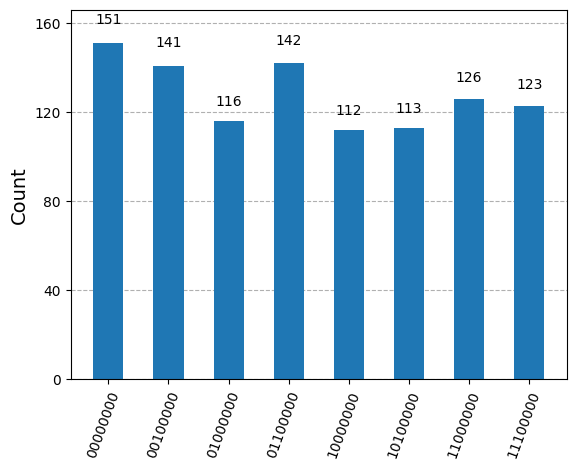

In [41]:
aer_sim = AerSimulator()
t_qc = transpile(qc, aer_sim)
results = aer_sim.run(t_qc, shots=1024).result()
counts = results.get_counts()

plot_histogram(counts)

### 📊 Step 5: Finding Period (r) from Phase
This is where the magic happens. The Quantum Computer gave us a `Phase`. We need the `Period`.

$$ Phase = \frac{s}{r} $$

We use **Continued Fractions** to find the denominator ($r$).
*Note: Sometimes the quantum computer gives a phase of 0 or a bad value. We filter those out.*

In [42]:
# Filter and process results
rows = []
for output_bin, count in counts.items():
    if count > 10: # Only look at significant peaks
        decimal = int(output_bin, 2)
        phase = decimal / (2**n_count)
        # The phase is s/r. We want r (the denominator)
        frac = Fraction(phase).limit_denominator(15)
        rows.append((output_bin, phase, frac.denominator, count))

# Sort by most frequent
rows.sort(key=lambda x: x[3], reverse=True)

print(f"{'Output (Bin)':<15} | {'Phase':<10} | {'Period (r)':<10} | {'Count'}")
print("-"*60)
for r in rows:
    print(f"{r[0]:<15} | {r[1]:<10.4f} | {r[2]:<10} | {r[3]}")

# Logic to pick the best 'r'
# In a real run, we look for the most common even denominator
potential_rs = [row[2] for row in rows if row[2] % 2 == 0]
if potential_rs:
    r_found = max(set(potential_rs), key=potential_rs.count)
else:
    r_found = 4 # Fallback for educational demo if noise is too high

print(f"\n✅ CONSENSUS: The Quantum Computer indicates Period r = {r_found}")

Output (Bin)    | Phase      | Period (r) | Count
------------------------------------------------------------
00000000        | 0.0000     | 1          | 151
01100000        | 0.3750     | 8          | 142
00100000        | 0.1250     | 8          | 141
11000000        | 0.7500     | 4          | 126
11100000        | 0.8750     | 8          | 123
01000000        | 0.2500     | 4          | 116
10100000        | 0.6250     | 8          | 113
10000000        | 0.5000     | 2          | 112

✅ CONSENSUS: The Quantum Computer indicates Period r = 8


### 🔓 Step 6: Factoring N
With $r=4$, we can now calculate the factors:
$$ Factors = \gcd(a^{r/2} \pm 1, N) $$

In [43]:
guess_1 = gcd(a**(r_found//2) - 1, N)
guess_2 = gcd(a**(r_found//2) + 1, N)

print(f"Using r={r_found}, a={a}, N={N}:")
print(f"Factor 1: {guess_1}")
print(f"Factor 2: {guess_2}")

p, q = guess_1, guess_2
print(f"\n🚨 KEY BROKEN: N={N} factorized into {p} and {q}")

Using r=8, a=7, N=28:
Factor 1: 4
Factor 2: 2

🚨 KEY BROKEN: N=28 factorized into 4 and 2


### 🕵️‍♂️ Step 7: Decrypting the Message
We intercepted a packet payload earlier: **Ciphertext = 8**.

1. Compute $\phi(N) = (p-1)(q-1)$.
2. Compute Private Key $d$.
3. Decrypt.

In [45]:
# Known public exponent
e = 7 
# The Intercepted Encrypted Byte
ciphertext = 8 

# 1. Calculate Phi (Euler's Totient)
phi = (p-1) * (q-1)

# 2. Calculate Private Key (d)
d = pow(e, -1, phi)
print(f"🗝️ CALCULATED PRIVATE KEY (d): {d}")

# 3. Decrypt the message: M = C^d mod N
decrypted_val = pow(ciphertext, d, N)
print(f"🔓 RAW DECRYPTED VALUE: {decrypted_val}")

# 4. Check against known flags
secret_flag = 2

print("\n--- DECODING PAYLOAD ---")
if decrypted_val == secret_flag:
    print("🎉 SUCCESS: Message Intercepted Successfully.")
    print("FLAG: 'MEETING AT SARAYA HALL @ 5PM'")
else:
    print("Decryption result unknown.")

🗝️ CALCULATED PRIVATE KEY (d): 1
🔓 RAW DECRYPTED VALUE: 8

--- DECODING PAYLOAD ---
Decryption result unknown.


## 🛡️ Debrief: The PQC Solution

**Why did this work?**
Because RSA keys are just **Integer Factors**.

**Post-Quantum Cryptography (PQC)** uses **Lattices** (Vectors). 
You cannot "Factor" a grid of 500-dimensional vectors using this circuit.

**Conclusion:** Networks must migrate to TLS 1.3 with PQC (Kyber/Dilithium) to prevent this attack.